In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

BASE = "/content/drive/MyDrive/thesis/data/group_1/openearable/"

participants = ["arda", "bas", "rachel"]
dfs = []

for p in participants:
    acc  = pd.read_csv(f"{BASE}{p}/{p}_acc.csv",  header=None, names=["ts","ax","ay","az","flag"])
    gyro = pd.read_csv(f"{BASE}{p}/{p}_gyro.csv", header=None, names=["ts","gx","gy","gz","flag"])
    mgnt = pd.read_csv(f"{BASE}{p}/{p}_mgnt.csv", header=None, names=["ts","mx","my","mz","flag"])
    baro = pd.read_csv(f"{BASE}{p}/{p}_baro.csv", header=None, names=["ts","baro","flag"])

    for df in [acc, gyro, mgnt, baro]:
        df.sort_values("ts", inplace=True)

    merged = pd.merge_asof(acc[["ts","ax","ay","az"]],
                           gyro[["ts","gx","gy","gz"]], on="ts", direction="nearest", tolerance=25000)
    merged = pd.merge_asof(merged,
                           mgnt[["ts","mx","my","mz"]], on="ts", direction="nearest", tolerance=25000)
    merged = pd.merge_asof(merged,
                           baro[["ts","baro"]],         on="ts", direction="nearest", tolerance=25000)

    merged["participant"] = p
    print(f"{p}: {len(merged)} rows, nulls: {merged.isnull().sum().sum()}")
    dfs.append(merged)

# save individual files
for p, df in zip(participants, dfs):
    df.to_csv(f"/content/drive/MyDrive/thesis/data/group_1/{p}_oe_merged.csv", index=False)
    print(f"saved {p}_oe_merged.csv")

arda: 99929 rows, nulls: 17
bas: 96731 rows, nulls: 226
rachel: 98755 rows, nulls: 70
saved arda_oe_merged.csv
saved bas_oe_merged.csv
saved rachel_oe_merged.csv


In [ ]:
all_oe = pd.concat(dfs, ignore_index=True).sort_values("ts").reset_index(drop=True)

print(f"Combined: {all_oe.shape}")
print(all_oe.head(10).to_string())

all_oe.to_csv("/content/drive/MyDrive/thesis/data/group_1/group1_oe.csv", index=False)
print("saved group1_oe.csv")

Combined: (295415, 12)
                 ts     ax     ay     az     gx     gy     gz      mx      my      mz  baro participant
0  1776759182912789 -7.001 -4.918  4.540  0.831  3.803 -0.861  4651.5  1056.3  4023.9   NaN        arda
1  1776759182932564 -7.001 -4.918  4.540  1.143  2.873 -0.991  4656.3  1058.7  4025.1   NaN        arda
2  1776759183231514 -8.574 -5.010  3.901  2.309  5.259 -1.227  4677.9  1056.3  4034.1   NaN        arda
3  1776759183251320 -8.574 -5.010  3.901  2.820  6.883 -1.273  4675.5  1061.1  4034.1   NaN        arda
4  1776759183369781 -2.766  7.240  6.932  2.614  4.428  2.820  4550.7   103.5  4295.1   NaN      rachel
5  1776759183389556 -2.766  7.240  6.932  2.462  5.457  3.674  4550.7   101.1  4292.7   NaN      rachel
6  1776759183409576 -2.766  7.240  6.932  2.454  5.617  3.979  4548.3   103.5  4293.3   NaN      rachel
7  1776759183558083 -8.523 -5.023  2.975  0.419 -0.899 -2.149  4699.5  1068.3  4043.1   NaN        arda
8  1776759183577889 -8.523 -5.023  2.975 

In [ ]:
import pandas as pd

BASE = "/content/drive/MyDrive/thesis/data/group_1/xsens/"

participants = ["arda", "bas", "rachel"]
dfs = []

for p in participants:
    df = pd.read_csv(f"{BASE}{p}.csv")
    df["participant"] = p
    print(f"{p}: {len(df)} rows  SampleTimeFine start={df['SampleTimeFine'].iloc[0]}")
    dfs.append(df)

xs_group = pd.concat(dfs, ignore_index=True).sort_values("SampleTimeFine").reset_index(drop=True)

print(f"\nCombined: {xs_group.shape}")
print(f"Columns: {list(xs_group.columns)}")
print(xs_group.head(5).to_string())

xs_group.to_csv("/content/drive/MyDrive/thesis/data/group_1/group1_xsens.csv", index=False)
print("\nsaved group1_xsens.csv")

arda: 60391 rows  SampleTimeFine start=1265302362
bas: 60389 rows  SampleTimeFine start=1265335696
rachel: 59997 rows  SampleTimeFine start=1265335696

Combined: (180777, 13)
Columns: ['PacketCounter', 'SampleTimeFine', 'Euler_X', 'Euler_Y', 'Euler_Z', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z', 'Unnamed: 11', 'participant']
   PacketCounter  SampleTimeFine    Euler_X               Euler_Y     Euler_Z     Acc_X     Acc_Y     Acc_Z       Gyr_X       Gyr_Y       Gyr_Z Unnamed: 11 participant
0              0      1265302362  10.574353             33.672272 -132.354523       0.0       0.0  0.000000         0.0    0.000000    0.000000                    arda
1              0      1265335696 -52.227863             15.955551  137.515900       0.0       0.0  0.000000         0.0    0.000000    0.000000                     bas
2              1      1265335696   4.108768             34.747932 -136.911758 -6.382371  3.834174  6.636262 -118.927048   17.281010 -117.481712                

In [ ]:
xs_group = pd.read_csv("/content/drive/MyDrive/thesis/data/group_1/group1_xsens.csv", low_memory=False)

# drop ghost column
xs_group = xs_group.drop(columns=["Unnamed: 11"], errors="ignore")

# clean non-numeric rows
for col in ["Acc_X","Acc_Y","Acc_Z","Gyr_X","Gyr_Y","Gyr_Z","Euler_X","Euler_Y","Euler_Z"]:
    xs_group = xs_group[pd.to_numeric(xs_group[col], errors="coerce").notna()]
    xs_group[col] = xs_group[col].astype(float)

# drop all-zero acc rows (corrupt packets)
xs_group = xs_group[~((xs_group["Acc_X"]==0) & (xs_group["Acc_Y"]==0) & (xs_group["Acc_Z"]==0))]
xs_group = xs_group.reset_index(drop=True)

print(f"Shape after cleaning: {xs_group.shape}")
print(f"Participant counts:\n{xs_group['participant'].value_counts()}")

xs_group.to_csv("/content/drive/MyDrive/thesis/data/group_1/group1_xsens.csv", index=False)
print("saved group1_xsens.csv")

Shape after cleaning: (180769, 12)
Participant counts:
participant
arda      60390
bas       60388
rachel    59991
Name: count, dtype: int64
saved group1_xsens.csv


FIXING ELAN LABELS

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/thesis/data/group_1/elan/Group_1.csv", header=None,
                 names=["tier","_","t_start_hms","t_start_s","t_end_hms","t_end_s","duration_hms","duration_s","label"])

# ── 1. typo / variant → canonical name ───────────────────────────────────────
typo_map = {
    # traveling
    "travel_between_units":                          "traveling_between_units",
    "traveling_betwen_units":                        "traveling_between_units",
    "trveling_between_units":                        "traveling_between_units",
    "moving_between_units":                          "traveling_between_units",
    # inspecting other pieces
    "inspecting_other_puzzle_pieces":                "inspecting_other_pieces",
    "inspecitng_other_puzlle_pieces":                "inspecting_other_pieces",
    "inspecting_puzzle_pieces":                      "inspecting_other_pieces",
    # inspecting pieces
    "inspecitng_pieces":                             "inspecting_pieces",
    # merging
    "merging_subpieces":                             "merging_subpiece",
    "merging_sub_pieces":                            "merging_subpiece",
    # carrying
    "carying_subpiece_with_tray":                    "carrying_subpiece_with_tray",
    "carrying_pieces":                               "carrying_piece",
    "carrying_object":                               "carrying_piece",
    "carrying_piece_to_table":                       "carrying_piece",
    # putting down tray
    "putting_doen_tray":                             "putting_down_tray",
    # task convo
    "task_related_social_convo":                     "task_social_convo",
    "task_operatinal_convo":                         "task_operational_convo",
    "task_operation_convo":                          "task_operational_convo",
    "task_realted_convo":                            "task_operational_convo",
    "task_related_dialouge":                         "task_operational_convo",
    # picking up
    "picking_up_pieces":                             "picking_up_piece",
    # building
    "buılding_subpiece_together":                    "building_subpiece_together",
    # searching
    "searching_for_piece":                           "searching_piece",
    # delivering/returning with initials
    "delivering_pieceBA":                            "delivering_piece",
    "delivering_pieceRB":                            "delivering_piece",
    "delivering_trayBR":                             "delivering_piece",
    "delivering_target_imageRB":                     "delivering_piece",
    "picking_up_target_image_fR":                    "lifting_target_image",
    "returning_target_image_tR":                     "returning_target_image",
    "object_handover_target_image":                  "object_handover",
}

df["label"] = df["label"].str.strip().replace(typo_map)

# ── 2. split compound labels into separate rows ───────────────────────────────
compound_map = {
    "inspecting_other_pieces +traveling_between units":        ["inspecting_other_pieces", "traveling_between_units"],
    "inspecting_target_image + task_operational_convo":        ["inspecting_target_image", "task_operational_convo"],
    "object_handover + task_operational_convo":                ["object_handover", "task_operational_convo"],
    "traveling_between_units + inspecting_target_image":       ["traveling_between_units", "inspecting_target_image"],
}

expanded = []
for _, row in df.iterrows():
    label = row["label"]
    if label in compound_map:
        for l in compound_map[label]:
            new_row = row.copy()
            new_row["label"] = l
            expanded.append(new_row)
    else:
        expanded.append(row)

df = pd.DataFrame(expanded).reset_index(drop=True)

# ── 3. remove sync move row ───────────────────────────────────────────────────
df = df[df["label"].str.strip().str.lower() != "synchronizaiton_move"].reset_index(drop=True)

# ── 4. verify ─────────────────────────────────────────────────────────────────
print(f"Total rows: {len(df)}")
print(f"\nFinal unique labels ({df['label'].nunique()}):")
for l in sorted(df["label"].unique().tolist()):
    print(f"  {l}")

df.to_csv("/content/drive/MyDrive/thesis/data/group_1/Group_1_clean.csv", index=False)
print("\nsaved Group_1_clean.csv")

Total rows: 180

Final unique labels (42):
  building_subpiece_together
  carrying_piece
  carrying_piece_by_tray
  carrying_subpiece_with_tray
  carrying_target_image
  carrying_tray
  carrying_tray_to_table
  delivering_piece
  help_request
  helping_task_mate
  inspecting_other_pieces
  inspecting_pieces
  inspecting_subpiece
  inspecting_target_image
  lifting_target_image
  lifting_tray
  merging_subpiece
  moving_pieces_to_central_table_with_tray
  moving_pieces_to_tray
  moving_subpieces_from_tray_to_table
  moving_subpieces_to_tray
  non_task_convo
  object_handover
  picking_up_piece
  picking_up_tray
  piece_and_image_matching
  piece_checking
  piece_presentation
  placing_pieces_to_tray
  placing_subpiece_from_tray_to_table
  placing_subpiece_to_tray
  presenting_piece
  putting_down_piece
  putting_down_target_image
  putting_down_tray
  returning_target_image
  searching_piece
  searching_target_image
  taking_others_puzzle_piece
  task_operational_convo
  task_social_con

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/thesis/data/group_1/Group_1_clean.csv")

collab_cutoff = {"Arda": 1420.0, "Bas": 1160.0, "Rachel": 1360.0}

new_rows = []

for participant, cutoff in collab_cutoff.items():
    p_elan = df[df["tier"] == participant].sort_values("t_start_s")

    # build merged covered intervals before cutoff
    covered = []
    for _, row in p_elan.iterrows():
        start = max(0, row["t_start_s"])
        end   = min(cutoff, row["t_end_s"])
        if start < end:
            covered.append([start, end])

    merged = []
    for start, end in sorted(covered):
        if merged and start <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], end)
        else:
            merged.append([start, end])

    # fill every gap from 0 to cutoff
    cursor = 0.0
    for start, end in merged:
        if start > cursor:
            new_rows.append({"tier": participant, "t_start_s": cursor, "t_end_s": start, "label": "individual_building"})
        cursor = max(cursor, end)

    if cursor < cutoff:
        new_rows.append({"tier": participant, "t_start_s": cursor, "t_end_s": cutoff, "label": "individual_building"})

new_df = pd.DataFrame(new_rows)
print(f"New individual_building rows: {len(new_df)}")
print(new_df.to_string())

# append and save
df_final = pd.concat([df, new_df], ignore_index=True).sort_values(["tier","t_start_s"]).reset_index(drop=True)
df_final.to_csv("/content/drive/MyDrive/thesis/data/group_1/Group_1_clean.csv", index=False)
print(f"\nSaved — total rows now: {len(df_final)}")

New individual_building rows: 55
      tier  t_start_s   t_end_s                label
0     Arda      0.000   242.927  individual_building
1     Arda    247.561   247.585  individual_building
2     Arda    248.976   302.455  individual_building
3     Arda    309.182   508.048  individual_building
4     Arda    514.095   841.636  individual_building
5     Arda    852.909   862.818  individual_building
6     Arda    864.818   867.000  individual_building
7     Arda    871.909   894.455  individual_building
8     Arda    899.455   960.182  individual_building
9     Arda    963.818   964.364  individual_building
10    Arda    967.455  1027.455  individual_building
11    Arda   1033.364  1033.455  individual_building
12    Arda   1040.455  1040.545  individual_building
13    Arda   1043.909  1296.000  individual_building
14    Arda   1304.455  1304.545  individual_building
15    Arda   1309.000  1369.634  individual_building
16    Arda   1374.683  1384.268  individual_building
17    Arda   

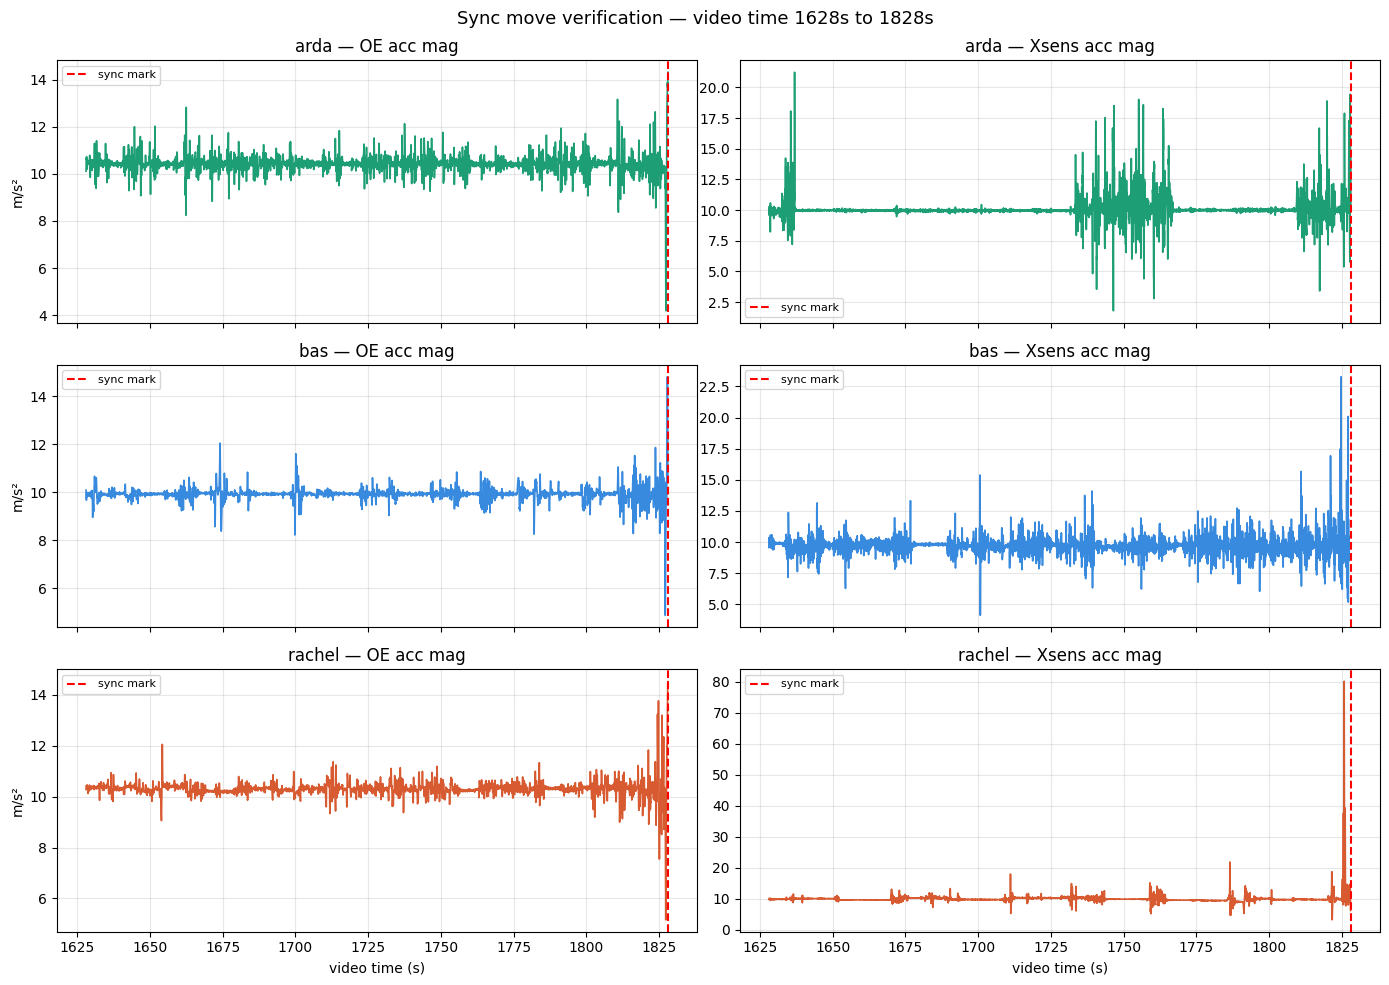

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load
oe = pd.read_csv("/content/drive/MyDrive/thesis/data/group_1/group1_oe.csv")
xs = pd.read_csv("/content/drive/MyDrive/thesis/data/group_1/group1_xsens.csv", low_memory=False)

VIDEO_SYNC_T = 1828.091

def detect_swing_peak(t, signal, search_window=300, swing_window=5.0):
    df = pd.DataFrame({"t": t.values, "sig": signal.values})
    df = df[df["t"] >= df["t"].iloc[-1] - search_window].reset_index(drop=True)
    best_swing, best_t = 0, None
    for i in range(len(df)):
        t0 = df.loc[i, "t"]
        w = df[(df["t"] >= t0) & (df["t"] <= t0 + swing_window)]
        if len(w) < 3: continue
        swing = w["sig"].max() - w["sig"].min()
        if swing > best_swing:
            best_swing = swing
            best_t = w.loc[w["sig"].idxmax(), "t"]
    return best_t, best_swing

# OE t_video
arda_oe = oe[oe["participant"] == "arda"].copy()
arda_oe["t"] = (arda_oe["ts"] - arda_oe["ts"].iloc[0]) / 1e6
arda_oe["acc_mag"] = np.sqrt(arda_oe["ax"]**2 + arda_oe["ay"]**2 + arda_oe["az"]**2)
oe_peak_t, _ = detect_swing_peak(arda_oe["t"], arda_oe["acc_mag"])
anchor_ts = arda_oe.loc[(arda_oe["t"] - oe_peak_t).abs().idxmin(), "ts"]
oe["t_video"] = (oe["ts"] - anchor_ts) / 1e6 + VIDEO_SYNC_T

# Xsens t_video
xs["Acc_X"] = pd.to_numeric(xs["Acc_X"], errors="coerce")
xs["Acc_Y"] = pd.to_numeric(xs["Acc_Y"], errors="coerce")
xs["Acc_Z"] = pd.to_numeric(xs["Acc_Z"], errors="coerce")
xs = xs.dropna(subset=["Acc_X","Acc_Y","Acc_Z"]).reset_index(drop=True)

arda_xs = xs[xs["participant"] == "arda"].copy()
arda_xs["t"] = (arda_xs["SampleTimeFine"] - arda_xs["SampleTimeFine"].iloc[0]) / 1e6
arda_xs["acc_mag"] = np.sqrt(arda_xs["Acc_X"]**2 + arda_xs["Acc_Y"]**2 + arda_xs["Acc_Z"]**2)
xs_peak_t, _ = detect_swing_peak(arda_xs["t"], arda_xs["acc_mag"])
xs_offset = VIDEO_SYNC_T - xs_peak_t

for name in xs["participant"].unique():
    mask = xs["participant"] == name
    start = xs.loc[mask, "SampleTimeFine"].iloc[0]
    xs.loc[mask, "t_video"] = (xs.loc[mask, "SampleTimeFine"] - start) / 1e6 + xs_offset

# plot
T_START = 1628
T_END   = 1828

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
fig.suptitle(f"Sync move verification — video time {T_START}s to {T_END}s", fontsize=13)

participants = ["arda", "bas", "rachel"]
colors = ["#1D9E75", "#378ADD", "#D85A30"]

for i, name in enumerate(participants):
    oe_p = oe[(oe["participant"] == name) & (oe["t_video"] >= T_START) & (oe["t_video"] <= T_END)].copy()
    oe_p["acc_mag"] = np.sqrt(oe_p["ax"]**2 + oe_p["ay"]**2 + oe_p["az"]**2)

    xs_p = xs[(xs["participant"] == name) & (xs["t_video"] >= T_START) & (xs["t_video"] <= T_END)].copy()
    xs_p["acc_mag"] = np.sqrt(xs_p["Acc_X"]**2 + xs_p["Acc_Y"]**2 + xs_p["Acc_Z"]**2)

    axes[i,0].plot(oe_p["t_video"], oe_p["acc_mag"], color=colors[i], lw=1.2)
    axes[i,0].axvline(1828.091, color="red", lw=1.5, linestyle="--", label="sync mark")
    axes[i,0].set_title(f"{name} — OE acc mag"); axes[i,0].set_ylabel("m/s²")
    axes[i,0].legend(fontsize=8); axes[i,0].grid(True, alpha=0.3)

    axes[i,1].plot(xs_p["t_video"], xs_p["acc_mag"], color=colors[i], lw=1.2)
    axes[i,1].axvline(1828.091, color="red", lw=1.5, linestyle="--", label="sync mark")
    axes[i,1].set_title(f"{name} — Xsens acc mag")
    axes[i,1].legend(fontsize=8); axes[i,1].grid(True, alpha=0.3)

for ax in axes[2]:
    ax.set_xlabel("video time (s)")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from datetime import datetime, timezone

oe = pd.read_csv("/content/drive/MyDrive/thesis/data/group_1/group1_oe.csv")

# show first and last timestamp as real clock time for each participant
for name in ["arda", "bas", "rachel"]:
    sub = oe[oe["participant"] == name]
    ts_start = sub["ts"].iloc[0] / 1e6  # microseconds → seconds
    ts_end   = sub["ts"].iloc[-1] / 1e6

    dt_start = datetime.fromtimestamp(ts_start, tz=timezone.utc)
    dt_end   = datetime.fromtimestamp(ts_end,   tz=timezone.utc)

    print(f"{name}: {dt_start.strftime('%H:%M:%S.%f')} → {dt_end.strftime('%H:%M:%S.%f')} UTC")

arda: 08:13:02.912789 → 08:46:23.989662 UTC
bas: 08:13:04.014408 → 08:46:19.276462 UTC
rachel: 08:13:03.369781 → 08:46:20.352478 UTC


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timezone

# ── anchor times ──────────────────────────────────────────────────────────────
VIDEO_START_UTC = datetime(2026, 4, 21, 8, 14, 47, tzinfo=timezone.utc).timestamp()
XSENS_START_UTC = datetime(2026, 4, 21, 8, 14, 22, tzinfo=timezone.utc).timestamp()

# ── load ──────────────────────────────────────────────────────────────────────
oe = pd.read_csv("/content/drive/MyDrive/thesis/data/group_1/group1_oe.csv")
xs = pd.read_csv("/content/drive/MyDrive/thesis/data/group_1/group1_xsens.csv", low_memory=False)

# ── OE t_video: absolute UTC from ts (microseconds) ──────────────────────────
oe["t_video"] = (oe["ts"] / 1e6) - VIDEO_START_UTC

# ── Xsens t_video: local t from SampleTimeFine + known start offset ───────────
xs["Acc_X"] = pd.to_numeric(xs["Acc_X"], errors="coerce")
xs["Acc_Y"] = pd.to_numeric(xs["Acc_Y"], errors="coerce")
xs["Acc_Z"] = pd.to_numeric(xs["Acc_Z"], errors="coerce")
xs = xs.dropna(subset=["Acc_X","Acc_Y","Acc_Z"]).reset_index(drop=True)

XSENS_OFFSET = XSENS_START_UTC - VIDEO_START_UTC  # = -25 seconds

for name in xs["participant"].unique():
    mask = xs["participant"] == name
    start = xs.loc[mask, "SampleTimeFine"].iloc[0]
    xs.loc[mask, "t_video"] = (xs.loc[mask, "SampleTimeFine"] - start) / 1e6 + XSENS_OFFSET

# ── verify ────────────────────────────────────────────────────────────────────
print(f"Xsens offset applied: {XSENS_OFFSET:.1f}s")
print(f"\nOE t_video per participant:")
for name in ["arda", "bas", "rachel"]:
    sub = oe[oe["participant"] == name]
    print(f"  {name}: {sub['t_video'].min():.1f}s to {sub['t_video'].max():.1f}s")

print(f"\nXsens t_video per participant:")
for name in ["arda", "bas", "rachel"]:
    sub = xs[xs["participant"] == name]
    print(f"  {name}: {sub['t_video'].min():.1f}s to {sub['t_video'].max():.1f}s")

Xsens offset applied: -25.0s

OE t_video per participant:
  arda: -104.1s to 1897.0s
  bas: -103.0s to 1892.3s
  rachel: -103.6s to 1893.4s

Xsens t_video per participant:
  arda: -25.0s to 1988.0s
  bas: -25.0s to 1987.9s
  rachel: -25.0s to 2916.7s


In [ ]:
# check Rachel's SampleTimeFine
rachel_xs = xs[xs["participant"] == "rachel"].copy()
rachel_xs["t"] = (rachel_xs["SampleTimeFine"] - rachel_xs["SampleTimeFine"].iloc[0]) / 1e6
print(f"Rachel Xsens duration: {rachel_xs['t'].iloc[-1]:.1f}s")
print(f"Rachel rows: {len(rachel_xs)}")
print(f"\nSampleTimeFine first 5:\n{rachel_xs['SampleTimeFine'].head().tolist()}")
print(f"SampleTimeFine last 5:\n{rachel_xs['SampleTimeFine'].tail().tolist()}")

# check for jumps
diff = rachel_xs["SampleTimeFine"].diff()
big_jumps = diff[diff > 1e8]
print(f"\nBig jumps in SampleTimeFine: {len(big_jumps)}")
print(big_jumps)

Rachel Xsens duration: 2941.7s
Rachel rows: 59991

SampleTimeFine first 5:
[1265369030, 1265402364, 1265435698, 1265469032, 1265502366]
SampleTimeFine last 5:
[3278209286, 3278242620, 3278275954, 3278309288, 4207038950]

Big jumps in SampleTimeFine: 1
180768    928729662.0
Name: SampleTimeFine, dtype: float64


In [ ]:
# find the jump index in Rachel's data
rachel_mask = xs["participant"] == "rachel"
rachel_xs = xs[rachel_mask].copy()

diff = rachel_xs["SampleTimeFine"].diff()
jump_idx = diff[diff > 1e8].index[0]
print(f"Jump at index {jump_idx}, keeping rows before it")
print(f"Before: {len(rachel_xs)} rows")

# keep only rows before the jump
xs = xs[~(rachel_mask & (xs.index >= jump_idx))].reset_index(drop=True)

rachel_xs_clean = xs[xs["participant"] == "rachel"].copy()
rachel_xs_clean["t"] = (rachel_xs_clean["SampleTimeFine"] - rachel_xs_clean["SampleTimeFine"].iloc[0]) / 1e6
print(f"After: {len(rachel_xs_clean)} rows, duration: {rachel_xs_clean['t'].iloc[-1]:.1f}s")

# recompute t_video for rachel
for name in xs["participant"].unique():
    mask = xs["participant"] == name
    start = xs.loc[mask, "SampleTimeFine"].iloc[0]
    xs.loc[mask, "t_video"] = (xs.loc[mask, "SampleTimeFine"] - start) / 1e6 + XSENS_OFFSET

print(f"\nXsens t_video per participant after fix:")
for name in ["arda", "bas", "rachel"]:
    sub = xs[xs["participant"] == name]
    print(f"  {name}: {sub['t_video'].min():.1f}s to {sub['t_video'].max():.1f}s")

Jump at index 180768, keeping rows before it
Before: 59991 rows
After: 59990 rows, duration: 2012.9s

Xsens t_video per participant after fix:
  arda: -25.0s to 1988.0s
  bas: -25.0s to 1987.9s
  rachel: -25.0s to 1987.9s


In [ ]:
import pandas as pd

elan = pd.read_csv("/content/drive/MyDrive/thesis/data/group_1/Group_1_clean.csv")

collab_cutoff = {"arda": 1420.0, "bas": 1160.0, "rachel": 1360.0}

participant_tiers = {
    "arda":   ["Arda",   "Bas_Arda", "Arda_Rachel", "Whole_Group"],
    "bas":    ["Bas",    "Bas_Rachel", "Bas_Arda",   "Whole_Group"],
    "rachel": ["Rachel", "Bas_Rachel", "Arda_Rachel", "Whole_Group"],
}

def label_df(df, time_col):
    df["label"] = ""
    for name, tiers in participant_tiers.items():
        elan_p = elan[elan["tier"].isin(tiers)][["t_start_s","t_end_s","label"]].dropna()
        mask = df["participant"] == name

        def get_label(t, ep=elan_p, cutoff=collab_cutoff[name]):
            active = ep[(ep["t_start_s"] <= t) & (ep["t_end_s"] > t)]["label"].tolist()
            if active:
                return "|".join(active)
            elif t < cutoff:
                return "individual_building"
            else:
                return ""

        df.loc[mask, "label"] = df.loc[mask, time_col].apply(get_label)
        coverage = (df.loc[mask, "label"] != "").mean() * 100
        print(f"  {name}: {coverage:.1f}% labelled")

    return df

print("Labelling OE:")
oe = label_df(oe, "t_video")

print("\nLabelling Xsens:")
xs = label_df(xs, "t_video")

oe.to_csv("/content/drive/MyDrive/thesis/data/group_1/group1_oe_labelled.csv", index=False)
xs.to_csv("/content/drive/MyDrive/thesis/data/group_1/group1_xsens_labelled.csv", index=False)

print("\nSaved group1_oe_labelled.csv")
print("Saved group1_xsens_labelled.csv")

Labelling OE:
  arda: 94.8% labelled
  bas: 94.1% labelled
  rachel: 95.2% labelled

Labelling Xsens:
  arda: 90.3% labelled
  bas: 89.2% labelled
  rachel: 90.5% labelled

Saved group1_oe_labelled.csv
Saved group1_xsens_labelled.csv


In [ ]:
import pandas as pd

def clean_labels(df):
    def fix_label(label):
        if pd.isna(label) or label == "":
            return "background"
        # split, deduplicate, sort, rejoin
        parts = [p.strip() for p in label.split("|")]
        parts = sorted(set(parts))
        return "|".join(parts)

    df["label"] = df["label"].apply(fix_label)
    return df

oe = pd.read_csv("/content/drive/MyDrive/thesis/data/group_1/group1_oe_labelled.csv")
xs = pd.read_csv("/content/drive/MyDrive/thesis/data/group_1/group1_xsens_labelled.csv", low_memory=False)

oe = clean_labels(oe)
xs = clean_labels(xs)

print("OE label distribution:")
print(oe["label"].value_counts().head(20).to_string())
print(f"\nUnique labels: {oe['label'].nunique()}")

print("\nXsens label distribution:")
print(xs["label"].value_counts().head(20).to_string())
print(f"\nUnique labels: {xs['label'].nunique()}")

oe.to_csv("/content/drive/MyDrive/thesis/data/group_1/group1_oe_labelled.csv", index=False)
xs.to_csv("/content/drive/MyDrive/thesis/data/group_1/group1_xsens_labelled.csv", index=False)
print("\nSaved both files")

OE label distribution:
label
individual_building                               129398
merging_subpiece                                   53122
individual_building|task_operational_convo         33163
individual_building|task_social_convo              18548
background                                         15737
traveling_between_units                             4994
building_subpiece_together|individual_building      4361
building_subpiece_together                          4286
individual_building|inspecting_other_pieces         2527
piece_and_image_matching                            2382
placing_pieces_to_tray                              1796
individual_building|inspecting_target_image         1318
placing_subpiece_to_tray                            1147
inspecting_target_image                             1118
individual_building|inspecting_subpiece             1063
individual_building|placing_subpiece_to_tray        1062
piece_presentation                                  1048
in

GROUP 1 FINAL ABOVE IS TRIAL

In [12]:
import pandas as pd
import numpy as np
from datetime import datetime, timezone

BASE            = "/content/drive/MyDrive/thesis/data/group_1/"
ELAN_FILE       = BASE + "elan/Group_1_clean.csv"
PARTICIPANTS    = ["arda", "bas", "rachel"]
VIDEO_START_UTC = datetime(2026, 4, 21, 8, 14, 47, tzinfo=timezone.utc).timestamp()
XSENS_START_UTC = datetime(2026, 4, 21, 8, 14, 22, tzinfo=timezone.utc).timestamp()
XSENS_OFFSET    = XSENS_START_UTC - VIDEO_START_UTC

participant_tiers = {
    "arda":   ["Arda",   "Bas_Arda", "Arda_Rachel", "Whole_Group"],
    "bas":    ["Bas",    "Bas_Rachel", "Bas_Arda",   "Whole_Group"],
    "rachel": ["Rachel", "Bas_Rachel", "Arda_Rachel", "Whole_Group"],
}
collab_cutoff = {"arda": 1420.0, "bas": 1160.0, "rachel": 1360.0}

elan = pd.read_csv(ELAN_FILE)

def load_oe(path, col_names):
    df = pd.read_csv(path, header=None, names=col_names)
    df = df[pd.to_numeric(df["ts"], errors="coerce").notna()].copy()
    df = df[pd.to_numeric(df[col_names[1]], errors="coerce").notna()].copy()
    df = df.astype({c: float for c in col_names if c != "flag"})
    return df.sort_values("ts").reset_index(drop=True)

def load_oe_all(base_path, p):
    acc       = load_oe(base_path + f"{p}_acc.csv",       ["ts","ax","ay","az","flag"])
    gyro      = load_oe(base_path + f"{p}_gyro.csv",      ["ts","gx","gy","gz","flag"])
    mgnt      = load_oe(base_path + f"{p}_mgnt.csv",      ["ts","mx","my","mz","flag"])
    baro      = load_oe(base_path + f"{p}_baro.csv",      ["ts","baro","flag"])
    bone_acc  = load_oe(base_path + f"{p}_bone_acc.csv",  ["ts","bx","by","bz","flag"])
    ppg       = load_oe(base_path + f"{p}_ppg.csv",       ["ts","ppg_red","ppg_ir","ppg_green","ppg_ambient","flag"])
    skin_temp = load_oe(base_path + f"{p}_skin_temp.csv", ["ts","skin_temp","flag"])
    env_temp  = load_oe(base_path + f"{p}_env_temp.csv",  ["ts","env_temp","flag"])

    merged = acc[["ts","ax","ay","az"]].copy()
    for df, cols in [
        (gyro,      ["ts","gx","gy","gz"]),
        (mgnt,      ["ts","mx","my","mz"]),
        (baro,      ["ts","baro"]),
        (bone_acc,  ["ts","bx","by","bz"]),
        (ppg,       ["ts","ppg_red","ppg_ir","ppg_green","ppg_ambient"]),
        (skin_temp, ["ts","skin_temp"]),
        (env_temp,  ["ts","env_temp"]),
    ]:
        merged = pd.merge_asof(merged, df[cols], on="ts", direction="nearest", tolerance=25000)
    merged["participant"] = p
    return merged

def label_df(df, time_col):
    df["label"] = ""
    for name, tiers in participant_tiers.items():
        elan_p = elan[elan["tier"].isin(tiers)][["t_start_s","t_end_s","label"]].dropna()
        mask = df["participant"] == name
        cutoff = collab_cutoff[name]

        def get_label(t, ep=elan_p, co=cutoff):
            active = ep[(ep["t_start_s"] <= t) & (ep["t_end_s"] > t)]["label"].tolist()
            if active:
                return "|".join(sorted(set(active)))
            elif t < co:
                return "individual_building"
            else:
                return "background"

        df.loc[mask, "label"] = df.loc[mask, time_col].apply(get_label)
        coverage = (df.loc[mask, "label"] != "background").mean() * 100
        print(f"  {name}: {coverage:.1f}% labelled")
    return df

# ── OE ────────────────────────────────────────────────────────────────────────
oe_all = []
for p in PARTICIPANTS:
    merged = load_oe_all(BASE + f"openearable/{p}/", p)
    print(f"OE {p}: {len(merged)} rows, {len(merged.columns)} cols, nulls: {merged.isnull().sum().sum()}")
    oe_all.append(merged)

oe = pd.concat(oe_all, ignore_index=True).sort_values(["ts","participant"]).reset_index(drop=True)
oe["t_video"] = (oe["ts"] / 1e6) - VIDEO_START_UTC

# ── Xsens ─────────────────────────────────────────────────────────────────────
xs = pd.read_csv(BASE + "group1_xsens.csv", low_memory=False)
xs = xs.drop(columns=["Unnamed: 11"], errors="ignore")
for col in ["Acc_X","Acc_Y","Acc_Z","Gyr_X","Gyr_Y","Gyr_Z","SampleTimeFine"]:
    xs = xs[pd.to_numeric(xs[col], errors="coerce").notna()]
    xs[col] = xs[col].astype(float)
xs = xs[~((xs["Acc_X"]==0) & (xs["Acc_Y"]==0) & (xs["Acc_Z"]==0))].reset_index(drop=True)

for p in PARTICIPANTS:
    mask = xs["participant"] == p
    start = xs.loc[mask, "SampleTimeFine"].iloc[0]
    xs.loc[mask, "t_video"] = (xs.loc[mask, "SampleTimeFine"] - start) / 1e6 + XSENS_OFFSET

print(f"\nOE t_video: {oe['t_video'].min():.1f} to {oe['t_video'].max():.1f}s")
print(f"Xsens t_video: {xs['t_video'].min():.1f} to {xs['t_video'].max():.1f}s")

# ── label ─────────────────────────────────────────────────────────────────────
print("\nLabelling OE:")
oe = label_df(oe, "t_video")
print("\nLabelling Xsens:")
xs = label_df(xs, "t_video")

# ── save ──────────────────────────────────────────────────────────────────────
oe.to_csv(BASE + "group1_oe_labelled.csv", index=False)
xs.to_csv(BASE + "group1_xsens_labelled.csv", index=False)
print(f"\nSaved group1_oe_labelled.csv — {len(oe)} rows, {len(oe.columns)} cols")
print(f"Saved group1_xsens_labelled.csv — {len(xs)} rows, {len(xs.columns)} cols")

OE arda: 99929 rows, 21 cols, nulls: 667
OE bas: 96731 rows, 21 cols, nulls: 6124
OE rachel: 98755 rows, 21 cols, nulls: 2254

OE t_video: -104.1 to 1897.0s
Xsens t_video: -25.0 to 2916.7s

Labelling OE:
  arda: 94.8% labelled
  bas: 94.1% labelled
  rachel: 95.2% labelled

Labelling Xsens:
  arda: 90.3% labelled
  bas: 89.2% labelled
  rachel: 90.5% labelled

Saved group1_oe_labelled.csv — 295415 rows, 23 cols
Saved group1_xsens_labelled.csv — 180769 rows, 14 cols


In [13]:
import pandas as pd

xs = pd.read_csv("/content/drive/MyDrive/thesis/data/group_1/group1_xsens_labelled.csv", low_memory=False)

# trim Rachel's jump
rachel_mask = xs["participant"] == "rachel"
diff = xs.loc[rachel_mask, "SampleTimeFine"].diff()
jumps = diff[diff > 1e8]
if len(jumps) > 0:
    first_jump = jumps.index[0]
    xs = xs[~(rachel_mask & (xs.index >= first_jump))].reset_index(drop=True)
    print(f"Trimmed Rachel — rows now: {len(xs[xs['participant']=='rachel'])}")

# recompute rachel t_video
XSENS_OFFSET = -25.0
rachel_only = xs["participant"] == "rachel"
start = xs.loc[rachel_only, "SampleTimeFine"].iloc[0]
xs.loc[rachel_only, "t_video"] = (xs.loc[rachel_only, "SampleTimeFine"] - start) / 1e6 + XSENS_OFFSET

print(f"Rachel t_video: {xs.loc[rachel_only,'t_video'].min():.1f} to {xs.loc[rachel_only,'t_video'].max():.1f}s")
print(f"All participants t_video: {xs['t_video'].min():.1f} to {xs['t_video'].max():.1f}s")
print(f"Shape: {xs.shape}")

xs.to_csv("/content/drive/MyDrive/thesis/data/group_1/group1_xsens_labelled.csv", index=False)
print("Saved group1_xsens_labelled.csv")

Trimmed Rachel — rows now: 59990
Rachel t_video: -25.0 to 1987.9s
All participants t_video: -25.0 to 1988.0s
Shape: (180768, 14)
Saved group1_xsens_labelled.csv


GROUP 2


In [2]:
import pandas as pd

elan = pd.read_csv("/content/drive/MyDrive/thesis/data/group_2/elan/Group_2.csv", header=None,
                   names=["tier","_","t_start_hms","t_start_s","t_end_hms","t_end_s","duration_hms","duration_s","label"])

# ── 1. typo / variant → canonical ────────────────────────────────────────────
typo_map = {
    # traveling
    "travel_between_units":                                      "traveling_between_units",
    "traveling_betwen_units":                                    "traveling_between_units",
    "travelin_between_units":                                    "traveling_between_units",
    # putting down piece
    "putting_doen_piece":                                        "putting_down_piece",
    "puting_down_piece":                                         "putting_down_piece",
    "putting_down_piece_fS":                                     "putting_down_piece",
    "putting_down_object":                                       "putting_down_piece",
    # inspecting
    "inspecitng_other_pieces":                                   "inspecting_other_pieces",
    "inspecitng_target_image":                                   "inspecting_target_image",
    "inspecting_piece":                                          "inspecting_pieces",
    # co-building
    "co_building_subpiece":                                      "building_subpiece_together",
    "co_building_sub_piece":                                     "building_subpiece_together",
    "co_building_subpart":                                       "building_subpiece_together",
    "co_building_sub_part":                                      "building_subpiece_together",
    "co_building_the_subpiece":                                  "building_subpiece_together",
    "co_builidng_subpiece":                                      "building_subpiece_together",
    # merging
    "mering_sub_pieces":                                         "merging_subpiece",
    "mering_subpieces":                                          "merging_subpiece",
    "merging_subpieces":                                         "merging_subpiece",
    # carrying tray
    "carrying_tray_to_centraltable":                             "carrying_tray_to_table",
    "carrying_tray_to_central_table":                            "carrying_tray_to_table",
    # placing subpiece
    "placing_sub_piece_to_tray":                                 "placing_subpiece_to_tray",
    "placing_subpieces_to_tray":                                 "placing_subpiece_to_tray",
    "placing_subpiece_to_centraltable":                          "placing_subpiece_to_tray",
    "placing_subpiece_to_centraltable_from_tray":                "placing_subpiece_to_tray",
    "placing_subpiece_from_tray_to_centraltable":                "placing_subpiece_to_tray",
    "co_placing_subpiece_to_tray":                               "placing_subpiece_to_tray",
    # convo
    "task_operational_talk":                                     "task_operational_convo",
    # matching
    "matching_pieces_with_image":                                "matching_pieces_to_target_image",
    # pointing → presenting
    "pointing_thowards_target_image":                            "presenting_target_image",
    # participant initials
    "picking_up_pieceS":                                         "picking_up_piece",
    "picking_up_piecefS":                                        "picking_up_piece",
    "picking_up_piece_fS":                                       "picking_up_piece",
    "picking_up_target_imageS":                                  "picking_up_target_image",
    "delivering_pieceS":                                         "delivering_piece",
    "delivering_piece_toS":                                      "delivering_piece",
}

elan["label"] = elan["label"].str.strip().replace(typo_map)

# ── 2. split compound labels ──────────────────────────────────────────────────
compound_map = {
    "picking_up_piece + traveling_between_units":                ["picking_up_piece", "traveling_between_units"],
    "putting_down_piece + traveling_between_units":              ["putting_down_piece", "traveling_between_units"],
    "inspecting_target_image + inspecting_pieces":               ["inspecting_target_image", "inspecting_pieces"],
    "inspecting_pieces + inspecting_target_image":               ["inspecting_pieces", "inspecting_target_image"],
    "inspecting_target_image + matching_pieces_to_target_image": ["inspecting_target_image", "matching_pieces_to_target_image"],
    "traveling_between_units + inspecting_other_pieces":         ["traveling_between_units", "inspecting_other_pieces"],
    "inspecitng_pieces + task_operational_convo":                ["inspecting_pieces", "task_operational_convo"],
}

expanded = []
for _, row in elan.iterrows():
    label = row["label"]
    if label in compound_map:
        for l in compound_map[label]:
            new_row = row.copy()
            new_row["label"] = l
            expanded.append(new_row)
    else:
        expanded.append(row)

elan = pd.DataFrame(expanded).reset_index(drop=True)

# ── 3. remove sync moves and markers ─────────────────────────────────────────
remove = {"khalil_synchornizaion_move", "droping_erarble_syncornaziton_move", "start_of_individual_build"}
elan = elan[~elan["label"].isin(remove)].reset_index(drop=True)

# ── 4. fix tier names (spaces → underscores for consistency) ─────────────────
elan["tier"] = elan["tier"].str.strip().str.replace(" ", "_")

# ── 5. verify ─────────────────────────────────────────────────────────────────
print(f"Total rows: {len(elan)}")
print(f"Tiers: {elan['tier'].unique().tolist()}")
print(f"\nUnique labels ({elan['label'].nunique()}):")
for l in sorted(elan["label"].unique().tolist()):
    print(f"  {l}")

elan.to_csv("/content/drive/MyDrive/thesis/data/group_2/elan/Group_2_clean.csv", index=False)
print("\nSaved Group_2_clean.csv")

Total rows: 233
Tiers: ['Arda', 'Shizin', 'Khalil', 'Arda_Shizin', 'Arda_Khalil', 'Shizin_Khalil', 'Whole_Group']

Unique labels (27):
  building_subpiece_together
  carrying_target_image
  carrying_tray
  carrying_tray_to_table
  delivering_piece
  delivering_target_image
  inspecting_other_pieces
  inspecting_pieces
  inspecting_target_image
  matching_pieces_to_target_image
  merging_subpiece
  moving_pieces_to_central_table_from_tray
  moving_pieces_to_tray
  object_handover
  picking_up_piece
  picking_up_target_image
  picking_up_tray
  placing_subpiece_to_tray
  presenting_piece
  presenting_target_image
  putting_down_piece
  putting_down_target_image
  putting_down_tray
  searching_piece
  searching_target_image
  task_operational_convo
  traveling_between_units

Saved Group_2_clean.csv


In [3]:
import pandas as pd

elan = pd.read_csv("/content/drive/MyDrive/thesis/data/group_2/elan/Group_2_clean.csv")

name_map = {
    "Khalil":         "Participant1",
    "Arda":           "Participant2",
    "Shizin":         "Participant3",
    "Arda_Khalil":    "Participant1_Participant2",
    "Arda_Shizin":    "Participant2_Participant3",
    "Shizin_Khalil":  "Participant1_Participant3",
}

elan["tier"] = elan["tier"].replace(name_map)

print("Tiers after renaming:", elan["tier"].unique().tolist())

elan.to_csv("/content/drive/MyDrive/thesis/data/group_2/elan/Group_2_clean.csv", index=False)
print("Saved Group_2_clean.csv")

Tiers after renaming: ['Participant2', 'Participant3', 'Participant1', 'Participant2_Participant3', 'Participant1_Participant2', 'Participant1_Participant3', 'Whole_Group']
Saved Group_2_clean.csv


In [4]:
import pandas as pd

elan = pd.read_csv("/content/drive/MyDrive/thesis/data/group_2/elan/Group_2_clean.csv")

collab_cutoff = {
    "Participant1": 1742.0,
    "Participant2": 1742.0,
    "Participant3": 1742.0,
}

new_rows = []

for participant, cutoff in collab_cutoff.items():
    p_elan = elan[elan["tier"] == participant].sort_values("t_start_s")

    covered = []
    for _, row in p_elan.iterrows():
        start = max(0, row["t_start_s"])
        end   = min(cutoff, row["t_end_s"])
        if start < end:
            covered.append([start, end])

    merged = []
    for start, end in sorted(covered):
        if merged and start <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], end)
        else:
            merged.append([start, end])

    cursor = 0.0
    for start, end in merged:
        if start > cursor:
            new_rows.append({"tier": participant, "t_start_s": cursor, "t_end_s": start, "label": "individual_building"})
        cursor = max(cursor, end)

    if cursor < cutoff:
        new_rows.append({"tier": participant, "t_start_s": cursor, "t_end_s": cutoff, "label": "individual_building"})

new_df = pd.DataFrame(new_rows)
print(f"New individual_building rows: {len(new_df)}")
print(new_df.to_string())

df_final = pd.concat([elan, new_df], ignore_index=True).sort_values(["tier","t_start_s"]).reset_index(drop=True)
df_final.to_csv("/content/drive/MyDrive/thesis/data/group_2/elan/Group_2_clean.csv", index=False)
print(f"\nSaved — total rows: {len(df_final)}")

New individual_building rows: 67
            tier  t_start_s   t_end_s                label
0   Participant1      0.000   498.586  individual_building
1   Participant1    501.215   503.143  individual_building
2   Participant1    507.072   522.015  individual_building
3   Participant1    524.386   524.415  individual_building
4   Participant1    528.329   546.551  individual_building
5   Participant1    549.476   578.545  individual_building
6   Participant1    582.727   582.818  individual_building
7   Participant1    588.000   588.091  individual_building
8   Participant1    594.727   621.455  individual_building
9   Participant1    623.182   623.273  individual_building
10  Participant1    627.273   639.545  individual_building
11  Participant1    644.727   806.000  individual_building
12  Participant1    810.545   894.545  individual_building
13  Participant1    900.364   925.000  individual_building
14  Participant1    930.000   940.545  individual_building
15  Participant1    943

In [9]:
import pandas as pd
import numpy as np
from datetime import datetime, timezone

BASE         = "/content/drive/MyDrive/thesis/data/group_2/"
ELAN_FILE    = BASE + "elan/Group_2_clean.csv"
PARTICIPANTS = ["Participant1", "Participant2", "Participant3"]

VIDEO_START_UTC = datetime(2026, 4, 21, 12, 4, 25, tzinfo=timezone.utc).timestamp()
XSENS_START_UTC = datetime(2026, 4, 21, 12, 7, 51, tzinfo=timezone.utc).timestamp()
XSENS_OFFSET    = XSENS_START_UTC - VIDEO_START_UTC

participant_tiers = {
    "Participant1": ["Participant1", "Participant1_Participant2", "Participant1_Participant3", "Whole_Group"],
    "Participant2": ["Participant2", "Participant1_Participant2", "Participant2_Participant3", "Whole_Group"],
    "Participant3": ["Participant3", "Participant1_Participant3", "Participant2_Participant3", "Whole_Group"],
}

collab_cutoff = {
    "Participant1": 1742.0,
    "Participant2": 1742.0,
    "Participant3": 1742.0,
}

elan = pd.read_csv(ELAN_FILE)

# ── helpers ───────────────────────────────────────────────────────────────────
def load_oe(path, col_names):
    df = pd.read_csv(path, header=None, names=col_names)
    df = df[pd.to_numeric(df["ts"], errors="coerce").notna()].copy()
    df = df[pd.to_numeric(df[col_names[1]], errors="coerce").notna()].copy()
    df = df.astype({c: float for c in col_names if c != "flag"})
    return df.sort_values("ts").reset_index(drop=True)

def load_oe_all(base_path, p):
    acc       = load_oe(base_path + f"{p}_acc.csv",       ["ts","ax","ay","az","flag"])
    gyro      = load_oe(base_path + f"{p}_gyro.csv",      ["ts","gx","gy","gz","flag"])
    mgnt      = load_oe(base_path + f"{p}_mgnt.csv",      ["ts","mx","my","mz","flag"])
    baro      = load_oe(base_path + f"{p}_baro.csv",      ["ts","baro","flag"])
    bone_acc  = load_oe(base_path + f"{p}_bone_acc.csv",  ["ts","bx","by","bz","flag"])
    ppg       = load_oe(base_path + f"{p}_ppg.csv",       ["ts","ppg_red","ppg_ir","ppg_green","ppg_ambient","flag"])
    skin_temp = load_oe(base_path + f"{p}_skin_temp.csv", ["ts","skin_temp","flag"])
    env_temp  = load_oe(base_path + f"{p}_env_temp.csv",  ["ts","env_temp","flag"])

    merged = acc[["ts","ax","ay","az"]].copy()
    for df, cols in [
        (gyro,      ["ts","gx","gy","gz"]),
        (mgnt,      ["ts","mx","my","mz"]),
        (baro,      ["ts","baro"]),
        (bone_acc,  ["ts","bx","by","bz"]),
        (ppg,       ["ts","ppg_red","ppg_ir","ppg_green","ppg_ambient"]),
        (skin_temp, ["ts","skin_temp"]),
        (env_temp,  ["ts","env_temp"]),
    ]:
        merged = pd.merge_asof(merged, df[cols], on="ts", direction="nearest", tolerance=25000)
    merged["participant"] = p
    return merged

# ── build OE ──────────────────────────────────────────────────────────────────
oe_all = []
for p in PARTICIPANTS:
    merged = load_oe_all(BASE + f"openearable/{p}/", p)
    print(f"OE {p}: {len(merged)} rows, {len(merged.columns)} cols, nulls: {merged.isnull().sum().sum()}")
    oe_all.append(merged)

oe = pd.concat(oe_all, ignore_index=True).sort_values(["ts","participant"]).reset_index(drop=True)
oe["t_video"] = (oe["ts"] / 1e6) - VIDEO_START_UTC

# ── load xsens ────────────────────────────────────────────────────────────────
xs_all = []
for p in PARTICIPANTS:
    df = pd.read_csv(BASE + f"xsens/{p}.csv", low_memory=False)
    df["participant"] = p
    xs_all.append(df)

xs = pd.concat(xs_all, ignore_index=True)
for col in ["Acc_X","Acc_Y","Acc_Z","Gyr_X","Gyr_Y","Gyr_Z","SampleTimeFine"]:
    xs = xs[pd.to_numeric(xs[col], errors="coerce").notna()]
    xs[col] = xs[col].astype(float)
xs = xs[~((xs["Acc_X"]==0) & (xs["Acc_Y"]==0) & (xs["Acc_Z"]==0))]

for p in PARTICIPANTS:
    mask = xs["participant"] == p
    diff = xs.loc[mask, "SampleTimeFine"].diff()
    jumps = diff[diff > 1e8]
    if len(jumps) > 0:
        print(f"WARNING: {p} Xsens has {len(jumps)} jumps — trimming")
        first_jump = jumps.index[0]
        xs = xs[~(mask & (xs.index >= first_jump))]

xs = xs.sort_values(["SampleTimeFine","participant"]).reset_index(drop=True)

for p in PARTICIPANTS:
    mask = xs["participant"] == p
    start = xs.loc[mask, "SampleTimeFine"].iloc[0]
    xs.loc[mask, "t_video"] = (xs.loc[mask, "SampleTimeFine"] - start) / 1e6 + XSENS_OFFSET

print(f"\nOE t_video range: {oe['t_video'].min():.1f} to {oe['t_video'].max():.1f}s")
print(f"Xsens t_video range: {xs['t_video'].min():.1f} to {xs['t_video'].max():.1f}s")

# ── label ─────────────────────────────────────────────────────────────────────
def label_df(df, time_col):
    df["label"] = ""
    for name, tiers in participant_tiers.items():
        elan_p = elan[elan["tier"].isin(tiers)][["t_start_s","t_end_s","label"]].dropna()
        mask = df["participant"] == name
        cutoff = collab_cutoff[name]

        def get_label(t, ep=elan_p, co=cutoff):
            active = ep[(ep["t_start_s"] <= t) & (ep["t_end_s"] > t)]["label"].tolist()
            if active:
                return "|".join(sorted(set(active)))
            elif t < co:
                return "individual_building"
            else:
                return "background"

        df.loc[mask, "label"] = df.loc[mask, time_col].apply(get_label)
        coverage = (df.loc[mask, "label"] != "background").mean() * 100
        print(f"  {name}: {coverage:.1f}% labelled")
    return df

print("\nLabelling OE:")
oe = label_df(oe, "t_video")
print("\nLabelling Xsens:")
xs = label_df(xs, "t_video")

oe.to_csv(BASE + "group2_oe_labelled.csv", index=False)
xs.to_csv(BASE + "group2_xsens_labelled.csv", index=False)
print("\nSaved group2_oe_labelled.csv")
print("Saved group2_xsens_labelled.csv")

OE Participant1: 142007 rows, 21 cols, nulls: 874
OE Participant2: 132547 rows, 21 cols, nulls: 22869
OE Participant3: 123936 rows, 21 cols, nulls: 49017

OE t_video range: 51.0 to 2907.4s
Xsens t_video range: 206.0 to 2990.9s

Labelling OE:
  Participant1: 95.9% labelled
  Participant2: 95.8% labelled
  Participant3: 96.2% labelled

Labelling Xsens:
  Participant1: 92.8% labelled
  Participant2: 92.6% labelled
  Participant3: 93.3% labelled

Saved group2_oe_labelled.csv
Saved group2_xsens_labelled.csv


In [10]:
xs = pd.read_csv("/content/drive/MyDrive/thesis/data/group_2/group2_xsens_labelled.csv", low_memory=False)
xs = xs.drop(columns=["Unnamed: 11"], errors="ignore")
xs.to_csv("/content/drive/MyDrive/thesis/data/group_2/group2_xsens_labelled.csv", index=False)
print(f"Fixed — columns: {list(xs.columns)}")

Fixed — columns: ['PacketCounter', 'SampleTimeFine', 'Euler_X', 'Euler_Y', 'Euler_Z', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z', 'participant', 't_video', 'label']


GROUP 3

In [2]:
import pandas as pd

# ── load both parts ───────────────────────────────────────────────────────────
p1 = pd.read_csv("/content/drive/MyDrive/thesis/data/group_3/elan/Group_3_Part1.csv", header=None,
                 names=["tier","_","t_start_hms","t_start_s","t_end_hms","t_end_s","duration_hms","duration_s","label"])

p2 = pd.read_csv("/content/drive/MyDrive/thesis/data/group_3/elan/Group_3_Part2.csv", header=None,
                 names=["tier","_","t_start_hms","t_start_s","t_end_hms","t_end_s","duration_hms","duration_s","label"])

# ── shift Part 2 timestamps to merged timeline ────────────────────────────────
PART2_OFFSET = 1506.0
p2["t_start_s"] = p2["t_start_s"] + PART2_OFFSET
p2["t_end_s"]   = p2["t_end_s"]   + PART2_OFFSET

# ── merge ─────────────────────────────────────────────────────────────────────
elan = pd.concat([p1, p2], ignore_index=True)

# ── rename tiers ──────────────────────────────────────────────────────────────
tier_map = {
    "chinyu":        "Participant1",
    "long":          "Participant2",
    "egemen":        "Participant3",
    "egemen chinyu": "Participant1_Participant3",
    "egemen long":   "Participant2_Participant3",
    "whole group":   "Whole_Group",
}
elan["tier"] = elan["tier"].str.strip().replace(tier_map)

# ── typo / variant → canonical ────────────────────────────────────────────────
typo_map = {
    # traveling
    "traveling_betwwen_units":                              "traveling_between_units",
    "traveling_between_unit":                               "traveling_between_units",
    # inspecting
    "inspecting_piece":                                     "inspecting_pieces",
    "inspecitng_pieces":                                    "inspecting_pieces",
    "picking_up_targetimage":                               "picking_up_target_image",
    # approaching
    "approaching_to_central_table":                         "traveling_between_units",
    "approaching_to_single_units":                          "traveling_between_units",
    # inspecting setup
    "inspecting_setup":                                     "inspecting_target_image",
    # co-building
    "co_building_subpiece":                                 "building_subpiece_together",
    "co_building_sub_piece":                                "building_subpiece_together",
    # merging
    "merging_sub_piece":                                    "merging_subpiece",
    "mering_subpieces":                                     "merging_subpiece",
    # moving
    "moving_subpiece_from_tray_to_central_table":           "moving_pieces_to_central_table_from_tray",
    "moving_subpiece_to_central_table_from_tray":           "moving_pieces_to_central_table_from_tray",
    "moving_subpiece_to_tray":                              "placing_subpiece_to_tray",
    "moving_tray_to_central_table":                         "carrying_tray_to_table",
    # matching
    "mathicng_pieces_to_target_image":                      "matching_pieces_to_target_image",
    # convo
    "task_operational_talk":                                "task_operational_convo",
    "task_operatşonal_convo":                               "task_operational_convo",
    # pointing
    "pointing_to_piece":                                    "presenting_piece",
}
elan["label"] = elan["label"].str.strip().replace(typo_map)

# ── split compound labels ─────────────────────────────────────────────────────
compound_map = {
    "approaching_to_central_table + task_operational_convo":      ["traveling_between_units", "task_operational_convo"],
    "task_operational_convo + isnpecting_setup":                   ["task_operational_convo", "inspecting_target_image"],
    "picking_up_target_image + traveling_between_units":           ["picking_up_target_image", "traveling_between_units"],
    "object_handover + task_operational_talk":                     ["object_handover", "task_operational_convo"],
    "putting_down_target_image + traveling_between_units":         ["putting_down_target_image", "traveling_between_units"],
    "putting_down_target_image + traveling_betwwen_units":         ["putting_down_target_image", "traveling_between_units"],
    "traveling_between_units + putting_down_piece":                ["traveling_between_units", "putting_down_piece"],
}

expanded = []
for _, row in elan.iterrows():
    label = row["label"]
    if label in compound_map:
        for l in compound_map[label]:
            new_row = row.copy()
            new_row["label"] = l
            expanded.append(new_row)
    else:
        expanded.append(row)

elan = pd.DataFrame(expanded).reset_index(drop=True)

# ── remove sync moves ─────────────────────────────────────────────────────────
elan = elan[~elan["label"].str.strip().str.lower().isin(["synchronaztion_move"])].reset_index(drop=True)

# ── add individual_building ───────────────────────────────────────────────────
collab_cutoff = {
    "Participant1": 2495.0,
    "Participant2": 2495.0,
    "Participant3": 2065.0,
}

new_rows = []
for participant, cutoff in collab_cutoff.items():
    p_elan = elan[elan["tier"] == participant].sort_values("t_start_s")

    covered = []
    for _, row in p_elan.iterrows():
        start = max(0, row["t_start_s"])
        end   = min(cutoff, row["t_end_s"])
        if start < end:
            covered.append([start, end])

    merged_intervals = []
    for start, end in sorted(covered):
        if merged_intervals and start <= merged_intervals[-1][1]:
            merged_intervals[-1][1] = max(merged_intervals[-1][1], end)
        else:
            merged_intervals.append([start, end])

    cursor = 0.0
    for start, end in merged_intervals:
        if start > cursor:
            new_rows.append({"tier": participant, "t_start_s": cursor, "t_end_s": start, "label": "individual_building"})
        cursor = max(cursor, end)
    if cursor < cutoff:
        new_rows.append({"tier": participant, "t_start_s": cursor, "t_end_s": cutoff, "label": "individual_building"})

elan = pd.concat([elan, pd.DataFrame(new_rows)], ignore_index=True).sort_values(["tier","t_start_s"]).reset_index(drop=True)

# ── verify ────────────────────────────────────────────────────────────────────
print(f"Total rows: {len(elan)}")
print(f"Tiers: {elan['tier'].unique().tolist()}")
print(f"Unique labels ({elan['label'].nunique()}):")
for l in sorted(elan["label"].dropna().unique().tolist()):
    print(f"  {l}")

elan.to_csv("/content/drive/MyDrive/thesis/data/group_3/elan/Group_3_clean.csv", index=False)
print("\nSaved Group_3_clean.csv")

Total rows: 166
Tiers: ['Participant1', 'Participant1_Participant3', 'Participant2', 'Participant2_Participant3', 'Participant3', 'Whole_Group']
Unique labels (22):
  building_subpiece_together
  carrying_tray_to_table
  delivering_piece
  individual_building
  inspecting_other_pieces
  inspecting_pieces
  inspecting_target_image
  matching_pieces_to_target_image
  merging_subpiece
  moving_pieces_to_central_table_from_tray
  object_handover
  picking_up_piece
  picking_up_target_image
  picking_up_tray
  placing_subpiece_to_tray
  presenting_piece
  putting_down_piece
  putting_down_target_image
  searching_target_image
  task_operational_convo
  task_social_convo
  traveling_between_units

Saved Group_3_clean.csv


In [7]:
import pandas as pd
import numpy as np
from datetime import datetime, timezone

# ── config ────────────────────────────────────────────────────────────────────
BASE         = "/content/drive/MyDrive/thesis/data/group_3/"
ELAN_FILE    = BASE + "elan/Group_3_clean.csv"
PARTICIPANTS = ["Participant1", "Participant2", "Participant3"]

VIDEO_START_UTC = datetime(2026, 4, 22, 12, 21, 50, tzinfo=timezone.utc).timestamp()
XSENS_START_UTC = datetime(2026, 4, 22, 12, 23, 31, tzinfo=timezone.utc).timestamp()
XSENS_OFFSET    = XSENS_START_UTC - VIDEO_START_UTC

participant_tiers = {
    "Participant1": ["Participant1", "Participant1_Participant2", "Participant1_Participant3", "Whole_Group"],
    "Participant2": ["Participant2", "Participant1_Participant2", "Participant2_Participant3", "Whole_Group"],
    "Participant3": ["Participant3", "Participant1_Participant3", "Participant2_Participant3", "Whole_Group"],
}

collab_cutoff = {
    "Participant1": 2495.0,
    "Participant2": 2495.0,
    "Participant3": 2065.0,
}

# ── helpers ───────────────────────────────────────────────────────────────────
def load_oe(path, col_names):
    df = pd.read_csv(path, header=None, names=col_names)
    df = df[pd.to_numeric(df["ts"], errors="coerce").notna()].copy()
    df = df[pd.to_numeric(df[col_names[1]], errors="coerce").notna()].copy()
    df = df.astype({c: float for c in col_names if c != "flag"})
    return df.sort_values("ts").reset_index(drop=True)

def load_oe_all(base_path, p):
    acc       = load_oe(base_path + f"{p}_acc.csv",       ["ts","ax","ay","az","flag"])
    gyro      = load_oe(base_path + f"{p}_gyro.csv",      ["ts","gx","gy","gz","flag"])
    mgnt      = load_oe(base_path + f"{p}_mgnt.csv",      ["ts","mx","my","mz","flag"])
    baro      = load_oe(base_path + f"{p}_baro.csv",      ["ts","baro","flag"])
    bone_acc  = load_oe(base_path + f"{p}_bone_acc.csv",  ["ts","bx","by","bz","flag"])
    ppg       = load_oe(base_path + f"{p}_ppg.csv",       ["ts","ppg_red","ppg_ir","ppg_green","ppg_ambient","flag"])
    skin_temp = load_oe(base_path + f"{p}_skin_temp.csv", ["ts","skin_temp","flag"])
    env_temp  = load_oe(base_path + f"{p}_env_temp.csv",  ["ts","env_temp","flag"])

    merged = acc[["ts","ax","ay","az"]].copy()
    for df, cols in [
        (gyro,      ["ts","gx","gy","gz"]),
        (mgnt,      ["ts","mx","my","mz"]),
        (baro,      ["ts","baro"]),
        (bone_acc,  ["ts","bx","by","bz"]),
        (ppg,       ["ts","ppg_red","ppg_ir","ppg_green","ppg_ambient"]),
        (skin_temp, ["ts","skin_temp"]),
        (env_temp,  ["ts","env_temp"]),
    ]:
        merged = pd.merge_asof(merged, df[cols], on="ts", direction="nearest", tolerance=25000)

    merged["participant"] = p
    return merged

# ── load elan ─────────────────────────────────────────────────────────────────
elan = pd.read_csv(ELAN_FILE)

# ── build OE ──────────────────────────────────────────────────────────────────
oe_all = []
for p in PARTICIPANTS:
    merged = load_oe_all(BASE + f"openearable/{p}/", p)
    print(f"OE {p}: {len(merged)} rows, {len(merged.columns)} cols, nulls: {merged.isnull().sum().sum()}")
    oe_all.append(merged)

oe = pd.concat(oe_all, ignore_index=True).sort_values(["ts","participant"]).reset_index(drop=True)
oe["t_video"] = (oe["ts"] / 1e6) - VIDEO_START_UTC

# ── load xsens ────────────────────────────────────────────────────────────────
xs_all = []
for p in PARTICIPANTS:
    df = pd.read_csv(BASE + f"xsens/{p}.csv", low_memory=False)
    df["participant"] = p
    xs_all.append(df)

xs = pd.concat(xs_all, ignore_index=True)
for col in ["Acc_X","Acc_Y","Acc_Z","Gyr_X","Gyr_Y","Gyr_Z","SampleTimeFine"]:
    xs = xs[pd.to_numeric(xs[col], errors="coerce").notna()]
    xs[col] = xs[col].astype(float)
xs = xs[~((xs["Acc_X"]==0) & (xs["Acc_Y"]==0) & (xs["Acc_Z"]==0))]

for p in PARTICIPANTS:
    mask = xs["participant"] == p
    diff = xs.loc[mask, "SampleTimeFine"].diff()
    jumps = diff[diff > 1e8]
    if len(jumps) > 0:
        print(f"WARNING: {p} Xsens has {len(jumps)} jumps — trimming")
        first_jump = jumps.index[0]
        xs = xs[~(mask & (xs.index >= first_jump))]

xs = xs.sort_values(["SampleTimeFine","participant"]).reset_index(drop=True)

for p in PARTICIPANTS:
    mask = xs["participant"] == p
    start = xs.loc[mask, "SampleTimeFine"].iloc[0]
    xs.loc[mask, "t_video"] = (xs.loc[mask, "SampleTimeFine"] - start) / 1e6 + XSENS_OFFSET

print(f"\nOE t_video range: {oe['t_video'].min():.1f} to {oe['t_video'].max():.1f}s")
print(f"Xsens t_video range: {xs['t_video'].min():.1f} to {xs['t_video'].max():.1f}s")

# ── label ─────────────────────────────────────────────────────────────────────
def label_df(df, time_col):
    df["label"] = ""
    for name, tiers in participant_tiers.items():
        elan_p = elan[elan["tier"].isin(tiers)][["t_start_s","t_end_s","label"]].dropna()
        mask = df["participant"] == name
        cutoff = collab_cutoff[name]

        def get_label(t, ep=elan_p, co=cutoff):
            active = ep[(ep["t_start_s"] <= t) & (ep["t_end_s"] > t)]["label"].tolist()
            if active:
                return "|".join(sorted(set(active)))
            elif t < co:
                return "individual_building"
            else:
                return "background"

        df.loc[mask, "label"] = df.loc[mask, time_col].apply(get_label)
        coverage = (df.loc[mask, "label"] != "background").mean() * 100
        print(f"  {name}: {coverage:.1f}% labelled")
    return df

print("\nLabelling OE:")
oe = label_df(oe, "t_video")
print("\nLabelling Xsens:")
xs = label_df(xs, "t_video")

# ── save ──────────────────────────────────────────────────────────────────────
oe.to_csv(BASE + "group3_oe_labelled.csv", index=False)
xs.to_csv(BASE + "group3_xsens_labelled.csv", index=False)
print("\nSaved group3_oe_labelled.csv")
print("Saved group3_xsens_labelled.csv")

OE Participant1: 123862 rows, 21 cols, nulls: 23877
OE Participant2: 127912 rows, 21 cols, nulls: 26411
OE Participant3: 137760 rows, 21 cols, nulls: 1468

OE t_video range: 23.5 to 2782.6s
Xsens t_video range: 101.0 to 2867.0s

Labelling OE:
  Participant1: 95.4% labelled
  Participant2: 96.7% labelled
  Participant3: 96.5% labelled

Labelling Xsens:
  Participant1: 92.8% labelled
  Participant2: 93.7% labelled
  Participant3: 93.5% labelled

Saved group3_oe_labelled.csv
Saved group3_xsens_labelled.csv


In [8]:
xs = pd.read_csv("/content/drive/MyDrive/thesis/data/group_3/group3_xsens_labelled.csv", low_memory=False)
xs = xs.drop(columns=["Unnamed: 11"], errors="ignore")
xs.to_csv("/content/drive/MyDrive/thesis/data/group_3/group3_xsens_labelled.csv", index=False)
print(f"Fixed — columns: {list(xs.columns)}")

Fixed — columns: ['PacketCounter', 'SampleTimeFine', 'Euler_X', 'Euler_Y', 'Euler_Z', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z', 'participant', 't_video', 'label']


GROUP 4